#Project Title

# AI Helpdesk Ticket Classifier using NLP & Machine Learning

# AI Helpdesk Ticket Classifier using NLP & Machine Learning

## Problem Statement
Organizations receive thousands of employee support tickets every day. Manually categorizing these tickets is time-consuming and inefficient.

## Objective
Develop a Machine Learning model that automatically classifies helpdesk tickets into predefined categories and suggests an appropriate response.

## Technologies
- Python
- Pandas
- Scikit-learn
- NLP
- TF-IDF
- Logistic Regression

##Project Objective

##Build an AI application that automatically classifies employee support tickets into categories such as:

* Password Reset
* Login Issues
* Leave Management
* Payroll
* Attendance
* IT Support
* Software Installation
* Account Access
* VPN Issues
* General HR Queries

The application will also provide an automated response and a confidence score.

| Technology          | Purpose            |
| ------------------- | ------------------ |
| Python              | Programming        |
| Pandas              | Data Processing    |
| Scikit-learn        | Machine Learning   |
| NLTK                | Text Cleaning      |
| TF-IDF              | Feature Extraction |
| Logistic Regression | Classification     |
| Joblib              | Save Model         |
| Streamlit           | Web Application    |
| GitHub              | Version Control    |
| Streamlit Cloud     | Deployment         |


# Work flow

User Ticket

      │
      ▼
Text Cleaning

      │
      ▼
TF-IDF Vectorization

      │
      ▼
Logistic Regression Model

      │
      ▼
Predicted Category

      │
      ▼
Knowledge Base

      │
      ▼
Automated Response

# Categories

| Category       | Example              |
| -------------- | -------------------- |
| Password Reset | Forgot password      |
| Login Issue    | Invalid credentials  |
| Leave Balance  | Check leave balance  |
| Attendance     | Attendance missing   |
| Payroll        | Salary not credited  |
| VPN            | VPN not working      |
| Email          | Outlook issue        |
| Software       | Install VS Code      |
| Account Access | Unlock account       |
| HR             | Policy clarification |


Dataset

↓

Text Cleaning

↓

Train Test Split

↓

TF-IDF

↓

Logistic Regression

↓

Model Evaluation

↓

Save Model

↓

Deploy with Streamlit

## Step 1: Import Libraries

In [224]:

import pandas as pd
import numpy as np

## Step 2 : Load Dataset





In [225]:
df = pd.read_csv('tickets.csv')

In [226]:
df.head()

,ticket,category,ticket_id,priority,submitted_by_dept,timestamp
0,"hi, facing an issue while trying to check the ...",HR Query,TCK1521,Medium,HR,2026-01-22
1,"hi, the server is pending. thanks.",Access Request,TCK1737,Medium,HR,2026-11-11
2,My VPN access is required. Please help. Regards.,Access Request,TCK1740,Medium,Sales,2026-08-12
3,Please help me connect the scanner. Regards.,Printer Issue,TCK1660,Low,IT,2026-12-28
4,The email account is not working.,Email Issue,TCK1411,Low,IT,2026-12-09


In [227]:
df.shape

(1000, 6)

## Step: EDA

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ticket             1000 non-null   object
 1   category           1000 non-null   object
 2   ticket_id          1000 non-null   object
 3   priority           1000 non-null   object
 4   submitted_by_dept  1000 non-null   object
 5   timestamp          1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB


In [229]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [230]:
df.isna().sum()

,0
ticket,0
category,0
ticket_id,0
priority,0
submitted_by_dept,0
timestamp,0


In [260]:
df['category'].value_counts()

,count
category,
Password Reset,73
Account Access,69
Network Issue,68
Login Issue,67
VPN Issue,65
Payroll,64
Access Request,63
Email Issue,62
Security/Phishing,61


In [232]:
df['priority'].value_counts()

,count
priority,
Medium,346
High,342
Low,312


In [233]:
df['submitted_by_dept'].value_counts()

,count
submitted_by_dept,
HR,183
Finance,176
Sales,174
Marketing,162
Operations,156
IT,149


In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
category_counts = df['category'].value_counts()

Text(0, 0.5, 'ticket_counts')

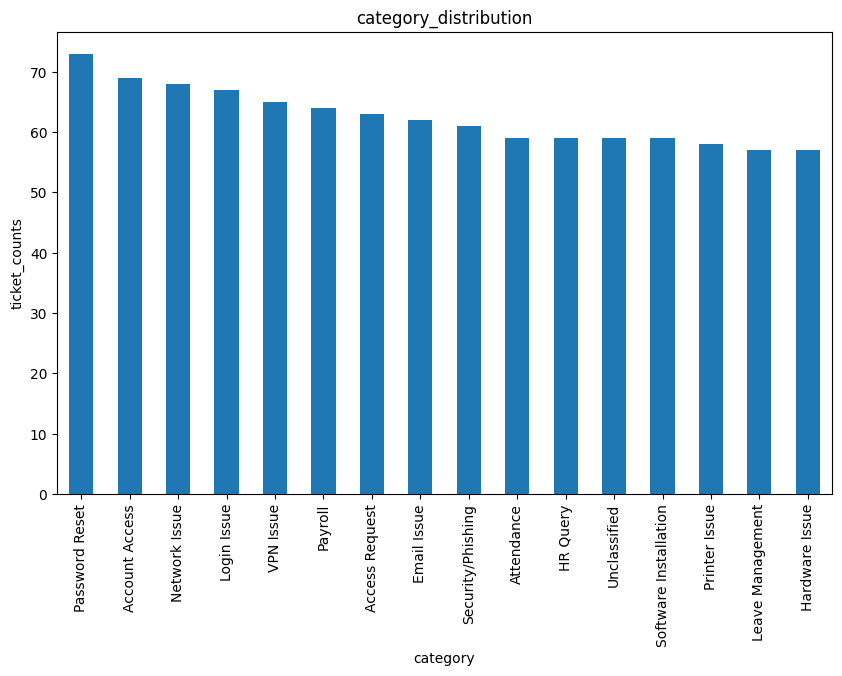

In [236]:
plt.figure(figsize=(10,6))
category_counts.plot(kind='bar')
plt.title('category_distribution')
plt.ylabel('ticket_counts')

## step 4:Text processing/cleaning

### Step 4.1 Import Required Libraries

In [237]:
import re
import nltk
from nltk.corpus import stopwords

In [238]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Step 4.2 Create the Cleaning Function

In [239]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

### Step 4.3 Apply Cleaning

In [240]:
df['clean_ticket'] = df['ticket'].apply(clean_text)

### Step 4.4 Compare Before & After

In [241]:
df[['ticket','clean_ticket']].head(10)

,ticket,clean_ticket
0,"hi, facing an issue while trying to check the ...",hi facing issue trying check employee handbook...
1,"hi, the server is pending. thanks.",hi server pending thanks
2,My VPN access is required. Please help. Regards.,vpn access required please help regards
3,Please help me connect the scanner. Regards.,please help connect scanner regards
4,The email account is not working.,email account working
5,"Hi team, My HP printer is ink low. Please help.",hi team hp printer ink low please help
6,Please resolve my network drive; it is slow.,please resolve network drive slow
7,FYI - Can you submit my HR policy?,fyi submit hr policy
8,Employee portal password is not working Regards.,employee portal password working regards
9,"Hi team, My leave request is incorrect. Please...",hi team leave request incorrect please help


In [242]:
df.head()

,ticket,category,ticket_id,priority,submitted_by_dept,timestamp,clean_ticket
0,"hi, facing an issue while trying to check the ...",HR Query,TCK1521,Medium,HR,2026-01-22,hi facing issue trying check employee handbook...
1,"hi, the server is pending. thanks.",Access Request,TCK1737,Medium,HR,2026-11-11,hi server pending thanks
2,My VPN access is required. Please help. Regards.,Access Request,TCK1740,Medium,Sales,2026-08-12,vpn access required please help regards
3,Please help me connect the scanner. Regards.,Printer Issue,TCK1660,Low,IT,2026-12-28,please help connect scanner regards
4,The email account is not working.,Email Issue,TCK1411,Low,IT,2026-12-09,email account working


### Step 5: Train-Test Split

In [243]:
from sklearn.model_selection import train_test_split

In [244]:
X = df['clean_ticket']
y = df['category']

In [245]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [246]:
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 800
Testing Samples  : 200


## Step 5: TF-IDF Vectorization

### Step 5.1 Import TF-IDF

In [247]:
from sklearn.feature_extraction.text import TfidfVectorizer

### 5.2.Create Vectorizer

In [248]:
#tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

### Step 5.3 Fit on Training Data and Transform
fit → Learns the vocabulary from the training data.

transform → Converts the text into TF-IDF vectors.

In [249]:
X_train_tfidf = tfidf.fit_transform(X_train)

### Step 5.4 Transform Test Data
Important: We use transform(), not fit_transform().

The model must use the same vocabulary learned from the training data.

In [250]:
X_test_tfidf = tfidf.transform(X_test)

### Step 5.5 Check the Shape


In [251]:
X_train_tfidf.shape

(800, 1564)

In [252]:
X_test_tfidf.shape

(200, 1564)

## Step 6: Train the Logistic Regression model

### Step 6.1 Import the Model

In [253]:
from sklearn.linear_model import LogisticRegression

In [254]:
lr_model = LogisticRegression()

In [255]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [256]:
print(lr_model.classes_)

['Access Request' 'Account Access' 'Attendance' 'Email Issue' 'HR Query'
 'Hardware Issue' 'Leave Management' 'Login Issue' 'Network Issue'
 'Password Reset' 'Payroll' 'Printer Issue' 'Security/Phishing'
 'Software Installation' 'Unclassified' 'VPN Issue']


## Step 7: Model Prediction & Evaluation

### Step 7.1 Predict on Test Data

In [257]:
y_pred = lr_model.predict(X_test_tfidf)

In [261]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

In [259]:
print("accuray", accuracy_score(y_test, y_pred))
print("Classification Report", classification_report(y_test, y_pred))
print("confusion matrix", confusion_matrix(y_test, y_pred))
print("precision", precision_score(y_test, y_pred, average='weighted'))
print("recall", recall_score(y_test, y_pred, average='weighted'))
print("f1_score", f1_score(y_test, y_pred, average='weighted'))

accuray 0.94
Classification Report                        precision    recall  f1-score   support

       Access Request       1.00      1.00      1.00        13
       Account Access       0.92      0.86      0.89        14
           Attendance       1.00      0.92      0.96        12
          Email Issue       1.00      1.00      1.00        12
             HR Query       1.00      1.00      1.00        12
       Hardware Issue       1.00      0.91      0.95        11
     Leave Management       1.00      1.00      1.00        11
          Login Issue       0.85      0.85      0.85        13
        Network Issue       0.87      0.93      0.90        14
       Password Reset       0.87      0.87      0.87        15
              Payroll       1.00      0.92      0.96        13
        Printer Issue       0.91      0.91      0.91        11
    Security/Phishing       0.86      1.00      0.92        12
Software Installation       1.00      1.00      1.00        12
         Unclassifi

### step 8: Save the model

In [262]:
import joblib
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(tfidf, 'tfidf.pkl')

['tfidf.pkl']